# Model Comparison and Analysis

This notebook compares the performance of multiple machine learning approaches for predictive maintenance classification.

The comparison focuses on:
- classification accuracy
- recall performance
- precision-recall tradeoffs
- overfitting behaviour
- operational suitability for predictive maintenance applications

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## RESULTS TABLE

In [2]:
results = pd.DataFrame({

    'Model': [
        'Decision Tree',
        'Logistic Regression',
        'Balanced Logistic Regression'
    ],

    'Accuracy': [
        0.976,
        0.9675,
        0.83
    ],

    'Recall': [
        0.63,
        0.12,
        0.85
    ],

    'Precision': [
        0.65,
        0.62,
        0.15
    ],

    'False Negatives': [
        25,
        60,
        10
    ],

    'False Positives': [
        23,
        5,
        330
    ]
})

results

,Model,Accuracy,Recall,Precision,False Negatives,False Positives
0,Decision Tree,0.9760,0.63,0.65,25,23
1,Logistic Regression,0.9675,0.12,0.62,60,5
2,Balanced Logistic Regression,0.8300,0.85,0.15,10,330


## ACCURACY COMPARISON

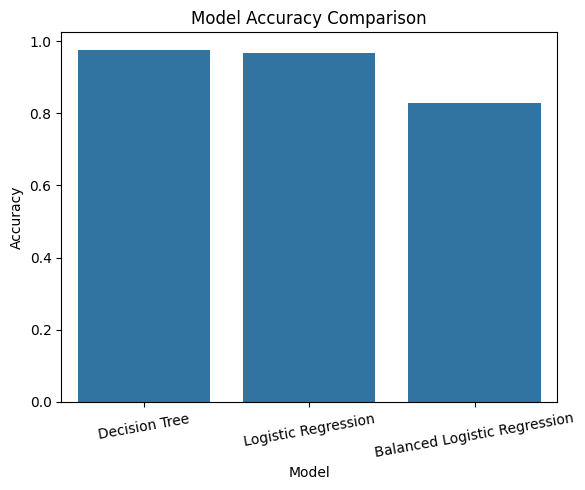

In [3]:
sns.barplot(
    x='Model',
    y='Accuracy',
    data=results
)

plt.title('Model Accuracy Comparison')

plt.xticks(rotation=10)

plt.show()

## RECALL COMPARISON

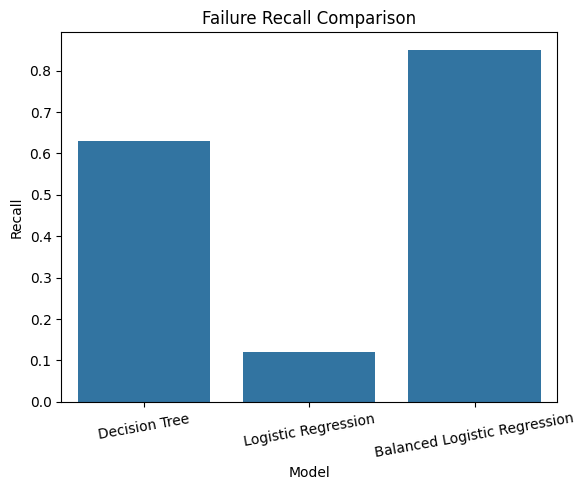

In [4]:
sns.barplot(
    x='Model',
    y='Recall',
    data=results
)

plt.title('Failure Recall Comparison')

plt.xticks(rotation=10)

plt.show()

## FALSE NEGATIVES COMPARISON

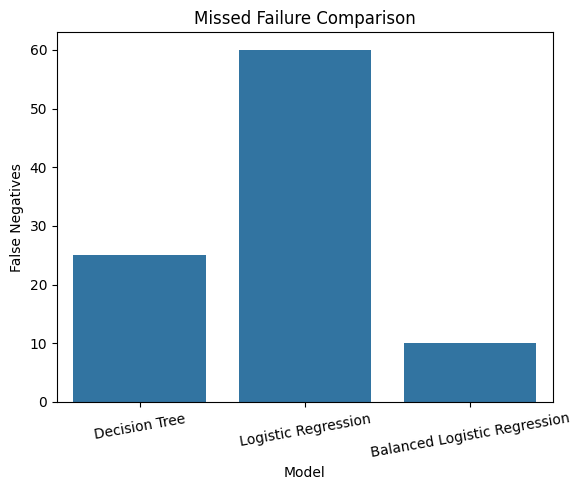

In [5]:
sns.barplot(
    x='Model',
    y='False Negatives',
    data=results
)

plt.title('Missed Failure Comparison')

plt.xticks(rotation=10)

plt.show()

# Comparative Analysis

The experiments demonstrated significant differences between the machine learning approaches.

The standard Logistic Regression model achieved relatively high overall accuracy but performed poorly when identifying machine failures, missing the majority of failure cases.

The Decision Tree classifier achieved a substantially better balance between recall and precision while maintaining strong overall accuracy.

Applying balanced class weighting to Logistic Regression significantly improved recall performance, reducing false negatives considerably. However, this introduced a large increase in false positives and reduced overall accuracy.

These results demonstrate the importance of selecting evaluation metrics appropriate to operational requirements, particularly when working with highly imbalanced predictive maintenance datasets.

## ROC Curves

ROC curves show:

- how well a model separates classes
- performance across different thresholds

In [8]:
from sklearn.metrics import roc_curve, auc

In [33]:
import pandas as pd

df = pd.read_csv('../data/predictive_maintenance.csv')

df_clean = df.drop(columns=['UDI', 'Product ID', 'Failure Type'])

df_clean = pd.get_dummies(df_clean, columns=['Type'])

df_clean = df_clean.astype(int, errors='ignore')

X = df_clean.drop('Target', axis=1)

y = df_clean['Target']

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

## Tarin Models

In [14]:
dt_model = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

dt_model.fit(X_train, y_train)


lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_model.fit(X_train_scaled, y_train)


balanced_lr = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight='balanced'
)

balanced_lr.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

## Get Probabilites

In [15]:
dt_probs = dt_model.predict_proba(X_test)[:, 1]

lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]

balanced_probs = balanced_lr.predict_proba(X_test_scaled)[:, 1]

## Genarate ROC Data 

In [16]:
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_probs)

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)

balanced_fpr, balanced_tpr, _ = roc_curve(y_test, balanced_probs)

## Calculate AUC

In [17]:
dt_auc = auc(dt_fpr, dt_tpr)

lr_auc = auc(lr_fpr, lr_tpr)

balanced_auc = auc(balanced_fpr, balanced_tpr)


## Plot Roc Curves

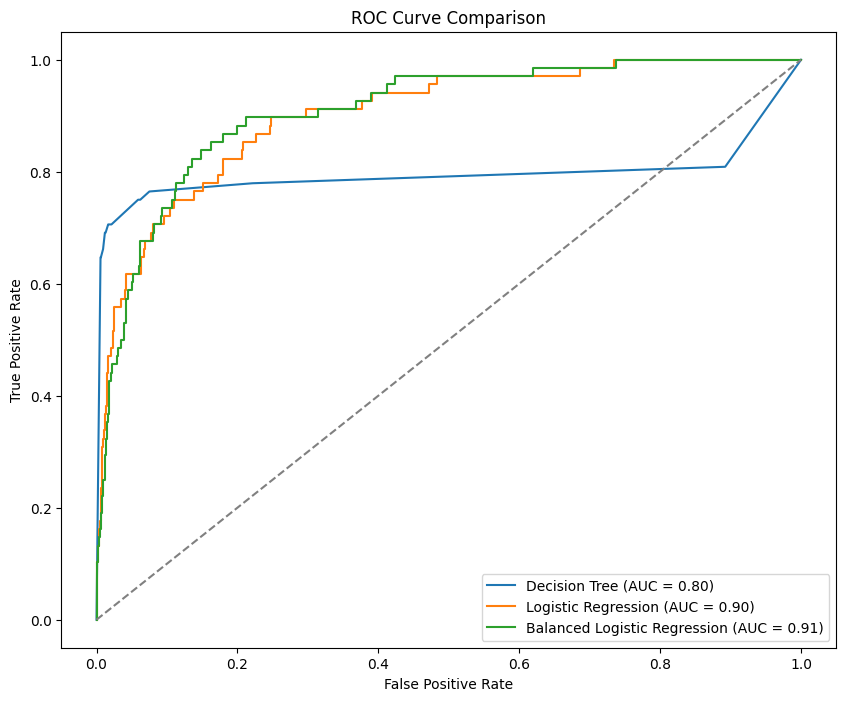

In [18]:
plt.figure(figsize=(10,8))

plt.plot(
    dt_fpr,
    dt_tpr,
    label=f'Decision Tree (AUC = {dt_auc:.2f})'
)

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f'Logistic Regression (AUC = {lr_auc:.2f})'
)

plt.plot(
    balanced_fpr,
    balanced_tpr,
    label=f'Balanced Logistic Regression (AUC = {balanced_auc:.2f})'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    color='gray'
)

plt.xlabel('False Positive Rate')

plt.ylabel('True Positive Rate')

plt.title('ROC Curve Comparison')

plt.legend()

plt.show()

## ROC Curve Analysis

ROC curve analysis showed that the Logistic Regression models achieved higher AUC scores than the Decision Tree classifier.

The standard Logistic Regression model achieved an AUC score of 0.90 despite poor recall performance at the default classification threshold.

This indicates that the model was capable of separating failure and non-failure observations probabilistically, but the default decision threshold was poorly suited to the highly imbalanced dataset.

Balanced Logistic Regression achieved the highest AUC score of 0.91 while also significantly improving recall performance.

These results demonstrate that classifier evaluation should consider both threshold-dependent metrics and probability-based performance measures when assessing predictive maintenance systems.

# FEATURE IMPORTANCE ANALYSIS

In [19]:
importance_df = pd.DataFrame({

    'Feature': X.columns,
    'Importance': dt_model.feature_importances_

})

In [20]:
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

importance_df

,Feature,Importance
3,Torque [Nm],0.317032
2,Rotational speed [rpm],0.213000
4,Tool wear [min],0.168457
0,Air temperature [K],0.150552
1,Process temperature [K],0.103863
6,Type_L,0.022059
7,Type_M,0.020987
5,Type_H,0.004049


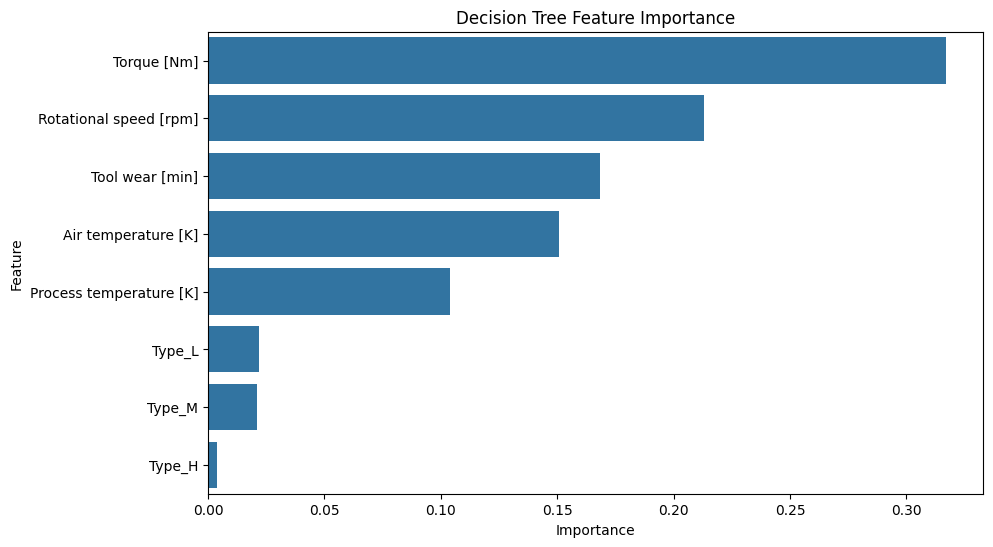

In [21]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df
)

plt.title('Decision Tree Feature Importance')

plt.show()

## Feature Importance Analysis

Feature importance analysis showed that torque, rotational speed, and tool wear were the most influential variables for predicting machine failures.

Torque was identified as the most important feature, suggesting that mechanical loading and operational stress are strong indicators of failure risk.

Rotational speed and tool wear also contributed significantly to classification performance, which aligns with real-world predictive maintenance expectations where excessive wear and abnormal operating conditions often precede equipment failure.

Temperature-related features showed moderate importance, while product type contributed relatively little predictive value.

Overall, the feature importance results appear physically meaningful and consistent with realistic engineering maintenance behaviour.